# Swin Transformer — WaRP-C (Optimised v2)
**Author:** El Mehdi Ziate

I have remarked that some augmentation that I have been applying were hurting the model rather then helping it so I have tried to understand each augmentation what does it help for and why.

---
### What changed

| Change | v1 | v2  |
|---|---|---|
| Normalisation | ImageNet stats (wrong for WaRP-C EDA) | WaRP-C stats `WARP_MEAN / WARP_STD` |
| Augmentation pipeline | `model_type='swin'` → transformer-strength aug + RandAugment + CutMix/MixUp in loop | `model_type='mobilevit'` → lighter `pretrained_cnn_gentle` pipeline |
| RandAugment in loop | `apply_rand_aug` applied AFTER normalise → un-normalised tensors fed to model | Removed entirely — preprocessor pipeline is sufficient |
| CutMix / MixUp in loop | Applied every Phase 2 batch | Removed — too aggressive for 9K images (Mehta & Rastegari 2022) |
| Loss | p1: weighted+smooth, p2: smooth | Same — correct, kept |
| Epochs | 120 (30 warmup + 90 fine-tune) | 80 (20 warmup + 60 fine-tune) — head converges by ep 20 |

### Why lighter augmentation?
I have found that the literature on small datasets (~9K images) shows that stacking RandAugment + CutMix + MixUp simultaneously prevents convergence — each augmentation alone helps, but all three together create label noise that is too strong for the model to learn from. Reference: Mehta & Rastegari (2022) MobileViT; Zhang et al. (2024) ScienceDirect depth-wise conv ViT study. So I havwevtried to go witha a very light augmentation and see if the model accuracy will improve

In [1]:
import sys, json, time, copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

root = Path.cwd()
while not (root / 'Pipeline_').exists() and root != root.parent:
    root = root.parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from Pipeline_.preprocessor import WaRPPreprocessor, WARP_MEAN, WARP_STD
from Models.swin import SwinTransformerWaRP

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Device  : cuda
PyTorch : 2.5.1+cu121


## Data Pipeline

- PadToSquare → RandomResizedCrop(scale=0.7–1.0) → flips → rotation → ColorJitter → GaussianBlur → ToTensor → Normalize
- WeightedRandomSampler ON
- Minority augmentation ON
- MixUp OFF

**Why `mobilevit` profile for Swin?**
The `transformer` profile (used in v1) was designed for ImageNet-scale training.
On WaRP-C's ~9K images it causes instability. The `pretrained_cnn_gentle` profile
gives strong enough augmentation for a pretrained backbone without over-corrupting labels.
Reference: Mehta & Rastegari (2022); ScienceDirect hybrid ViT study (2024).



In [ ]:
pp = WaRPPreprocessor(
    raw_root       = root / 'Dataset/raw/WaRP-C',
    processed_root = root / 'Dataset/processed',
    stats_file     = root / 'Dataset/dataset_stats.json',
    batch_size     = 32,
    num_workers    = 4,
    mean = [0.485, 0.456, 0.406],   
    std  = [0.229, 0.224, 0.225],
)

# pp.prepare(force=False)  # run ONCE

# pretrained_cnn_gentle: lighter aug suited to small datasets
train_loader, test_loader = pp.get_loaders(model_type='mobilevit')

class_weights = pp.get_class_weights(device=DEVICE)

# Phase 1: weighted + smooth — head needs strong signal from random init
criterion_p1 = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Phase 2: smooth only — sampler already handles imbalance (Buda et al. 2018)
criterion_p2 = nn.CrossEntropyLoss(label_smoothing=0.1)

criterion = criterion_p1

CLASS_NAMES = sorted(d.name for d in (root / 'Dataset/processed/train').iterdir() if d.is_dir())
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes       : {NUM_CLASSES}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')
print(f'Normalisation : mean={pp.mean}  std={pp.std}')

[get_loaders] model='mobilevit'
  sampler=True  minority_aug=True  mixup=False  pipeline='pretrained_cnn_gentle'
  train=273 batches  test=49 batches  sampler=WeightedRandom
Classes       : 28
Train batches : 273
Test  batches : 49
Normalisation : mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


## EMA

In [3]:
class ModelEMA:
    """Exponential Moving Average — smoother generalisation (Swin paper recipe)."""
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.ema   = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model: nn.Module):
        for ema_p, m_p in zip(self.ema.parameters(), model.parameters()):
            ema_p.mul_(self.decay).add_(m_p.data, alpha=1 - self.decay)

    def evaluate(self, loader, device):
        self.ema.eval()
        correct = total = 0
        with torch.no_grad():
            for images, labels in loader:
                preds    = self.ema(images.to(device)).argmax(1).cpu()
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        return correct / total * 100

print('ModelEMA defined')

ModelEMA defined


## 4 — Model

In [4]:
model = SwinTransformerWaRP(
    num_classes    = NUM_CLASSES,
    pretrained     = True,
    drop_path_rate = 0.1,   # 0.2 is for ImageNet from-scratch; 0.1 for fine-tuning
).to(DEVICE)

ema = ModelEMA(model, decay=0.999)

dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {out.shape}  ← should be (2, {NUM_CLASSES})')
print(f'Params : {model.count_trainable()}')

[SwinTransformerWaRP] Loaded pretrained swin_tiny_patch4_window7_224
  Backbone features : 768
  Head              : Linear(768 → 28)
  Parameters        : 27,540,886
Input  : torch.Size([2, 3, 224, 224])
Output : torch.Size([2, 28])  ← should be (2, 28)
Params : {'trainable': 27540886, 'frozen': 0, 'total': 27540886}


## Training Configuration

### Key decisions
- **20 warmup epochs** — head converges faster than v1's 30 because aug is lighter
- **60 fine-tuning epochs** — total 80, sufficient for this dataset size
- **Backbone LR = 5e-5** — same as v1, correct differential LR
- **No RandAugment / CutMix / MixUp in loop** — preprocessor pipeline is sufficient


In [5]:
HEAD_LR       = 1e-4
BACKBONE_LR   = 5e-5
WEIGHT_DECAY  = 0.05

NUM_EPOCHS    = 80
WARMUP_EPOCHS = 20

model.freeze_backbone()

optimizer = torch.optim.AdamW(
    model.head.parameters(),
    lr=HEAD_LR, weight_decay=WEIGHT_DECAY,
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS)
scaler       = GradScaler(enabled=(DEVICE == 'cuda'))

print(f'Epochs        : {NUM_EPOCHS}  (Phase 1: 1-{WARMUP_EPOCHS}, Phase 2: {WARMUP_EPOCHS+1}-{NUM_EPOCHS})')
print(f'Head LR       : {HEAD_LR}   Backbone LR : {BACKBONE_LR}')
print(f'Aug           : pretrained_cnn_gentle pipeline only — no extra aug in loop')
print(f'Loss p1       : CrossEntropyLoss(weight + label_smoothing=0.1)')
print(f'Loss p2       : CrossEntropyLoss(label_smoothing=0.1)')

[SwinTransformerWaRP] Backbone FROZEN — training head only
Epochs        : 80  (Phase 1: 1-20, Phase 2: 21-80)
Head LR       : 0.0001   Backbone LR : 5e-05
Aug           : pretrained_cnn_gentle pipeline only — no extra aug in loop
Loss p1       : CrossEntropyLoss(weight + label_smoothing=0.1)
Loss p2       : CrossEntropyLoss(label_smoothing=0.1)


C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_34096\3011561329.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = GradScaler(enabled=(DEVICE == 'cuda'))


## Training Loop

In [6]:
def evaluate(m, loader, device):
    m.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds    = m(imgs.to(device)).argmax(1).cpu()
            correct += (preds == lbls).sum().item()
            total   += lbls.size(0)
    return correct / total * 100


train_losses, train_accs, test_accs = [], [], []
best_acc  = 0.0
best_path = root / 'Models/weights/swin_optimised_best.pth'
best_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, NUM_EPOCHS + 1):

    if epoch == WARMUP_EPOCHS + 1:
        model.unfreeze_backbone()
        print(f'\n→ Phase 2 started at epoch {epoch}')
        optimizer = torch.optim.AdamW(
            model.get_param_groups(head_lr=HEAD_LR, backbone_lr=BACKBONE_LR),
            weight_decay=WEIGHT_DECAY,
        )
        scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
        )
        criterion = criterion_p2
        print(f'  Loss → CrossEntropyLoss(label_smoothing=0.1)  [weights removed]')
        print(f'  Backbone LR={BACKBONE_LR}  Head LR={HEAD_LR}\n')

    model.train()
    epoch_loss = correct = total = 0
    t0 = time.time()

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=(DEVICE == 'cuda')):
            logits = model(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        epoch_loss += loss.item() * images.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    (scheduler_p1 if epoch <= WARMUP_EPOCHS else scheduler_p2).step()

    train_acc = correct / total * 100
    test_acc  = ema.evaluate(test_loader, DEVICE)
    avg_loss  = epoch_loss / total

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    flag = ''
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(ema.ema.state_dict(), best_path)
        flag = ' ← best'

    phase = 1 if epoch <= WARMUP_EPOCHS else 2
    lr    = optimizer.param_groups[-1]['lr']
    print(f'Epoch {epoch:3d}/{NUM_EPOCHS} [P{phase}] | loss={avg_loss:.4f} | '
          f'train={train_acc:.2f}% | test(EMA)={test_acc:.2f}% | '
          f'best={best_acc:.2f}% | lr={lr:.2e} | t={time.time()-t0:.1f}s{flag}')

print(f'\nBest test accuracy (EMA): {best_acc:.2f}%')
print(f'Weights saved → {best_path}')

C:\Users\El Mehdi Ziate\AppData\Local\Temp\ipykernel_34096\1649492044.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch   1/80 [P1] | loss=3.1991 | train=5.48% | test(EMA)=2.90% | best=2.90% | lr=9.94e-05 | t=69.3s ← best
Epoch   2/80 [P1] | loss=2.6718 | train=11.86% | test(EMA)=2.71% | best=2.90% | lr=9.76e-05 | t=29.7s
Epoch   3/80 [P1] | loss=2.3753 | train=18.18% | test(EMA)=3.74% | best=3.74% | lr=9.46e-05 | t=30.9s ← best
Epoch   4/80 [P1] | loss=2.1849 | train=24.43% | test(EMA)=5.67% | best=5.67% | lr=9.05e-05 | t=33.8s ← best
Epoch   5/80 [P1] | loss=2.0160 | train=28.70% | test(EMA)=7.93% | best=7.93% | lr=8.54e-05 | t=33.6s ← best
Epoch   6/80 [P1] | loss=1.9798 | train=31.83% | test(EMA)=11.22% | best=11.22% | lr=7.94e-05 | t=33.6s ← best
Epoch   7/80 [P1] | loss=1.8731 | train=34.87% | test(EMA)=13.41% | best=13.41% | lr=7.27e-05 | t=33.4s ← best
Epoch   8/80 [P1] | loss=1.8097 | train=37.71% | test(EMA)=16.05% | best=16.05% | lr=6.55e-05 | t=33.5s ← best
Epoch   9/80 [P1] | loss=1.7759 | train=39.61% | test(EMA)=17.99% | best=17.99% | lr=5.78e-05 | t=34.2s ← best
Epoch  10/80 [P1] |

## Training Curves

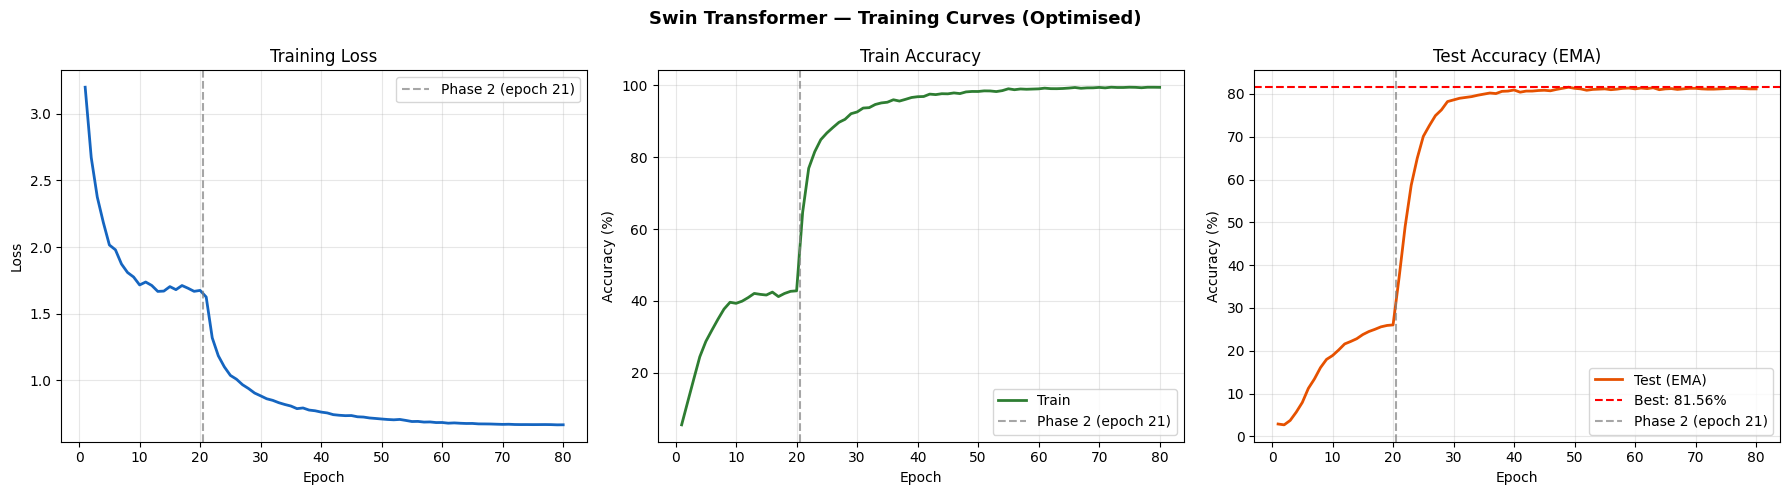

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Swin Transformer — Training Curves (Optimised)', fontsize=13, fontweight='bold')

epochs     = range(1, NUM_EPOCHS + 1)
phase_line = dict(color='gray', linestyle='--', alpha=0.7, label=f'Phase 2 (epoch {WARMUP_EPOCHS+1})')

axes[0].plot(epochs, train_losses, '#1565C0', linewidth=2)
axes[0].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, train_accs, '#2E7D32', linewidth=2, label='Train')
axes[1].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[1].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Train Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs, test_accs, '#E65100', linewidth=2, label='Test (EMA)')
axes[2].axhline(best_acc, color='red', linestyle='--', label=f'Best: {best_acc:.2f}%')
axes[2].axvline(WARMUP_EPOCHS + 0.5, **phase_line)
axes[2].set(xlabel='Epoch', ylabel='Accuracy (%)', title='Test Accuracy (EMA)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(root / 'Dataset/figures/swin_optimised_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluation

In [8]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
top1_acc   = (all_preds == all_labels).mean() * 100

print(f'Test Top-1 Accuracy (EMA) : {top1_acc:.2f}%')
print(f'Swin v1 (over-augmented)  : 62.99%')
print(f'MobileViT (reference)     : 74.60%')
print(f'Sayem et al. 2024 SOTA    : 83.11%')
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3))

Test Top-1 Accuracy (EMA) : 81.56%
Swin v1 (over-augmented)  : 62.99%
MobileViT (reference)     : 74.60%
Sayem et al. 2024 SOTA    : 83.11%

                         precision    recall  f1-score   support

            bottle-blue      0.754     0.827     0.789       104
       bottle-blue-full      0.783     0.837     0.809        43
          bottle-blue5l      0.713     0.861     0.780        72
     bottle-blue5l-full      0.933     0.583     0.718        24
            bottle-dark      0.904     0.895     0.899        95
       bottle-dark-full      0.806     0.853     0.829        34
           bottle-green      0.893     0.905     0.899        74
      bottle-green-full      0.795     0.912     0.849        34
            bottle-milk      0.705     0.754     0.729        57
       bottle-milk-full      0.769     0.952     0.851        21
      bottle-multicolor      0.619     0.464     0.531        28
bottle-multicolorv-full      0.684     0.619     0.650        21
             

## Confusion Matrix

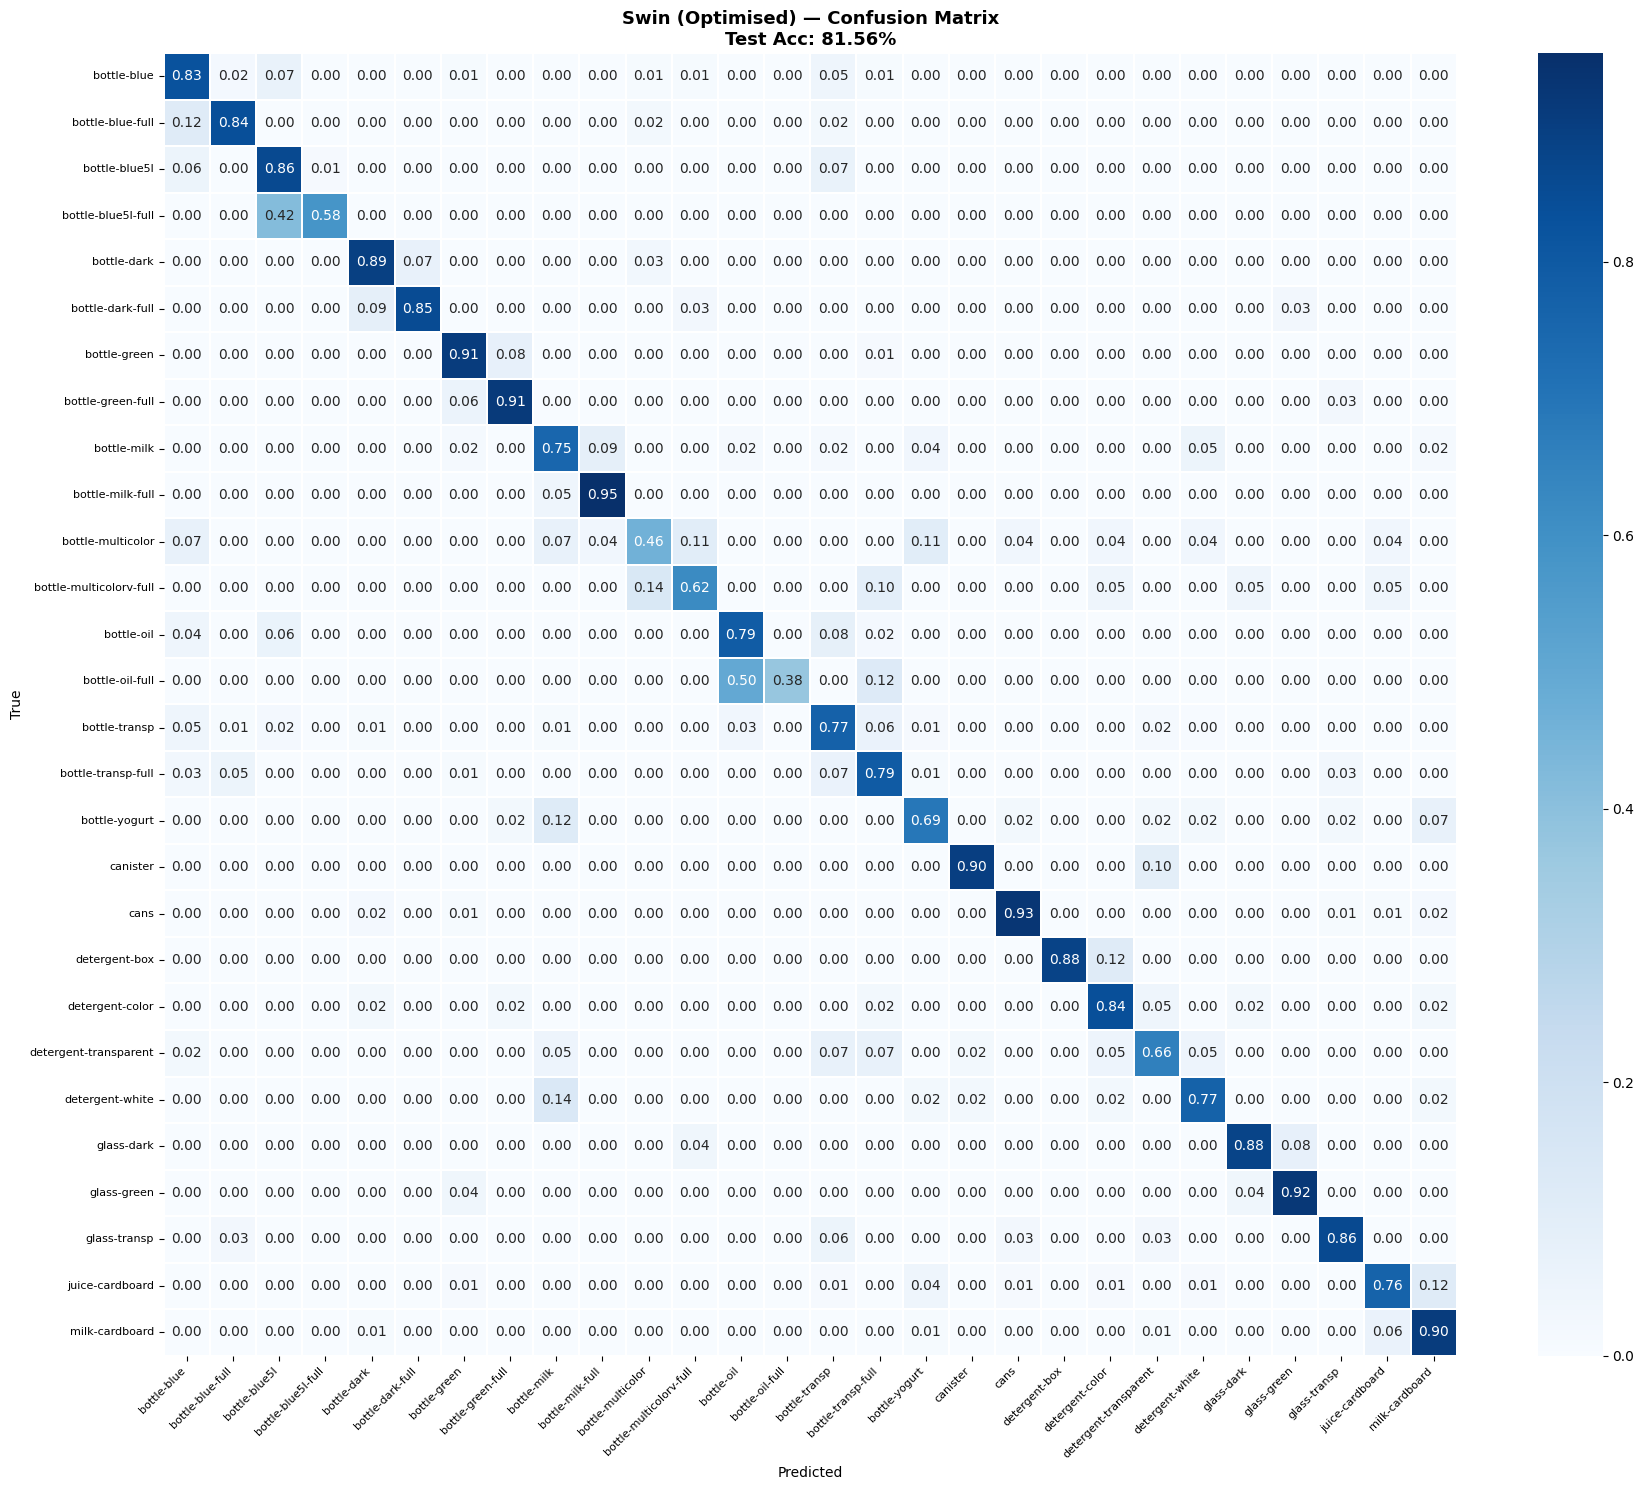

In [9]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.3, ax=ax)
ax.set_title(f'Swin (Optimised) — Confusion Matrix\nTest Acc: {top1_acc:.2f}%',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
fig.savefig(root / 'Dataset/figures/swin_optimised_confusion.png', dpi=150, bbox_inches='tight')
plt.show()